In [1]:
import numpy as np
import pandas as pd
import copy

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from pathlib import Path
import glob

%matplotlib inline

In [2]:
import os

In [5]:
"""
Auto-reload external *.py modules on change before
each cell runs, no kernel restart needed.
"""
%load_ext autoreload
%autoreload 2

In [6]:
"""
Fijar semilla AL PRINCIPIO del notebook para garantizar reproducibilidad de resultados.
Esto asegura que cada ejecución del notebook produzca exactamente los mismos valores:
- Inicialización de pesos de la red neuronal
- División aleatoria de datos (validation_split)
- Mezcla de lotes (shuffle) durante el entrenamiento
- Operaciones de dropout (si se utilizan)
- Cualquier otra fuente de aleatoriedad en TensorFlow, NumPy y Python
"""

from scripts.set_seed import set_seed
set_seed(42)  # Fijada globalmente para todo el notebook

In [7]:
import sys
sys.path.append('scripts/')

In [8]:
from set_seed import main as test_set_seed
test_set_seed()

Ejecutando pruebas...
✓ Prueba de reproducibilidad exitosa!
✓ Prueba de seeds diferentes exitosa!
✓ Prueba de secuencia reproducible exitosa!
✓ Prueba de reproducibilidad de TensorFlow exitosa!

🎉 Todas las pruebas pasaron exitosamente!


/home/xopi/.pyenv/versions/3.13.2/envs/MEGAsync__IT_xopi_UNIR_MasterAI__04_TFM__CODE__digitial-twins-PVDAQ/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
from scripts.process_plant_export_metrics import *
from scripts.utils import *
from scripts.proccess_previous_to_model import *

# Load dataset

In [10]:
# Path to the dataset directory
dataset_path = "dataset/"

# Find all CSV files that end with "training.csv"
file_pattern = os.path.join(dataset_path, "*training.csv")
csv_files = glob.glob(file_pattern)

# List to store dataframes
dfs = []

# Read each CSV file and append to list
for file in sorted(csv_files):
    df = pd.read_csv(file)
    
    # print(df.info())
    if len(df) > 0:
        dfs.append(df)
        # print(f"CSV {file} added to dfs. Rows: {df.shape[0]:5d}")
    else:
        print(f"CSV {file} has 0 rows")

df = pd.concat(dfs, ignore_index=True)
df.shape

CSV dataset/pvdt_9068_2022_08_training.csv has 0 rows


(297643, 10)

# Prepocesado

In [11]:
from scripts.process_plant_export_metrics import process_plant_export_metrics

df = process_plant_export_metrics(df)

In [12]:
# Check NaN
df.isna().sum()

timestamp                     0
plant_ac_power_kw             0
inverter_1_ac_power_kw        0
inverter_2_ac_power_kw        0
poa_irradiance_wm2            0
ambient_temperature_c         0
module_temperature_c          0
hour                          0
dayofyear                     0
month                         0
total_inverter_ac_power_kw    0
plant_export_power_kw         0
meter_vs_inverter_diff_kw     0
meter_vs_inverter_diff_pct    0
dtype: int64

## Load PCA and scaler

In [13]:
from scripts.get_data_AWS import load_model
scaler = load_model('models/scaler_after_clean.pkl')
model_pca = load_model('models/pca_after_clean_norm.pkl')

Modelo cargado exitosamente
Tipo de modelo: <class 'sklearn.preprocessing._data.StandardScaler'>
Features esperadas: ['ambient_temperature_c' 'doy_cos' 'doy_sin' 'hour_cos' 'hour_sin'
 'module_temperature_c' 'poa_irradiance_wm2']
Modelo cargado exitosamente
Tipo de modelo: <class 'sklearn.decomposition._pca.PCA'>
Features esperadas: ['ambient_temperature_c' 'doy_cos' 'doy_sin' 'hour_cos' 'hour_sin'
 'module_temperature_c' 'poa_irradiance_wm2']


## Get `features`

In [14]:
TARGET = 'total_inverter_ac_power_kw'

features = model_pca.feature_names_in_

# Get `features` for apply_scaler()
if 'features' not in dir():
    df_previous_to_model, train_df, test_df = proccess_previous_to_model(df)
    features = sorted(set(train_df.columns) - set([TARGET]))
features

array(['ambient_temperature_c', 'doy_cos', 'doy_sin', 'hour_cos',
       'hour_sin', 'module_temperature_c', 'poa_irradiance_wm2'],
      dtype=object)

# Apply scaler & PCA

In [15]:
# Preprocess
df_previous_to_model = proccess_previous_to_model_fit(df)
df_previous_to_model.isna().sum()

timestamp                     0
plant_ac_power_kw             0
inverter_1_ac_power_kw        0
inverter_2_ac_power_kw        0
poa_irradiance_wm2            0
ambient_temperature_c         0
module_temperature_c          0
hour                          0
dayofyear                     0
month                         0
total_inverter_ac_power_kw    0
plant_export_power_kw         0
meter_vs_inverter_diff_kw     0
meter_vs_inverter_diff_pct    0
hour_sin                      0
hour_cos                      0
doy_sin                       0
doy_cos                       0
dtype: int64

In [16]:
from scripts.outliers import remove_outliers_high_threshold
from scripts.proccess_previous_to_model import get_train_test_dfs, apply_scaler

# Remove outliers
df_previous_to_model_clean = remove_outliers_high_threshold(df_previous_to_model, threshold=4) # same threshold as in 01.ipynb

# Z-scaler (all but "timestamp" and TARGET)
# scaler previously loaded
df_previous_to_model_clean_norm, scaler = apply_scaler(df_previous_to_model_clean, scaler=scaler, columns_to_scale=features)

# Get train & test
train_df_clean_norm, test_df_clean_norm = get_train_test_dfs(df_previous_to_model_clean_norm)

X_train_clean_norm = train_df_clean_norm[features]
y_train_clean = train_df_clean_norm[TARGET]

X_test_clean_norm = test_df_clean_norm[features]
y_test_clean = test_df_clean_norm[TARGET]

Columnas excluidas (std ≤ 1e-10): ['plant_export_power_kw']
Evaluando outliers en 16 columnas variables
Eliminadas 2572 filas de 290322 (0.89%)
Filas restantes: 287750


# GaussianFeatures

In [17]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class GaussianFeatures(BaseEstimator, TransformerMixin):
    """Gaussian basis functions for multi-dimensional input.
    
    For each feature dimension, creates N equally spaced centers along that
    feature's range, then computes RBF activation. Output shape:
    (n_samples, N * n_features)
    """
    
    def __init__(self, N=10, width_factor=2.0):
        self.N = N
        self.width_factor = width_factor
    
    def fit(self, X, y=None):
        X = np.asarray(X)
        self.n_features_in_ = X.shape[1]
        
        # Create centers for each feature dimension
        self.centers_ = []
        self.widths_ = []
        
        for i in range(self.n_features_in_):
            feature_min = X[:, i].min()
            feature_max = X[:, i].max()
            centers = np.linspace(feature_min, feature_max, self.N)
            width = self.width_factor * (centers[1] - centers[0]) if self.N > 1 else 1.0
            self.centers_.append(centers)
            self.widths_.append(width)
        
        return self
    
    def transform(self, X):
        X = np.asarray(X)
        n_samples = X.shape[0]
        # Pre-allocate output: (n_samples, N * n_features)
        X_out = np.empty((n_samples, self.N * self.n_features_in_))
        
        for i in range(self.n_features_in_):
            # For feature i, compute Gaussian activations
            centers = self.centers_[i]
            width = self.widths_[i]
            # Shape: (n_samples, N)
            arg = (X[:, i, np.newaxis] - centers) / width
            activations = np.exp(-0.5 * arg**2)
            # Store in the output slice
            start = i * self.N
            end = (i + 1) * self.N
            X_out[:, start:end] = activations
        
        return X_out

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge

cv = 3 # 5-fold (common default); 10-fold (traditional choice); 3- or 4-fold (for large datasets)
N_arr = [20, 50]          # number of Gaussian centers per feature
width_factor_arr = [.2, .5, 1.0]
ridge_alpha_arr = [0.1, 1.0]

# Best R² = 0.6257 with {'N': 15, 'width_factor': 1.0, 'alpha': 1.0}

In [19]:
%%time

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

X, y = model_pca.transform(X_train_clean_norm), y_train_clean

if False:
    # GridSearchCV stores all models, my df has 290k rows --> huge memory needed
    
    # Pipeline    
    # pipeline = Pipeline([...
    pass

else:
    # Manual grid search – only one model at a time

    best_score = -np.inf
    best_params = None

    for N in N_arr:
        for width_factor in width_factor_arr:
            for alpha in ridge_alpha_arr:
                pipe = make_pipeline(
                    GaussianFeatures(N=N, width_factor=width_factor),
                    Ridge(alpha=alpha)
                )
                # Use fewer CV folds to reduce memory
                scores = cross_val_score(pipe, X, y, cv=cv, 
                                         scoring='r2',
                                         n_jobs=-1 if N<20 else +1 # Avoid n_jobs=-1 to prevent multiple large matrices simultaneously
                                        )
                mean_score = scores.mean()
                
                if mean_score > best_score:
                    best_score = mean_score
                    best_params = {
                        'N': N,
                        'width_factor': width_factor,
                        'alpha': alpha
                    }
                
                print(f"N={N:2d}, width={width_factor:3.1f}, alpha={alpha:5.3f}: {mean_score:.4f}")
    
    print(f"\nBest R² = {best_score:.4f} with {best_params}")
    
    # Retrain best model on full data
    model_gaussian = make_pipeline(
        GaussianFeatures(N=best_params['N'], width_factor=best_params['width_factor']),
        Ridge(alpha=best_params['alpha'])
    )
    model_gaussian.fit(X, y)

N=20, width=0.2, alpha=0.100: 0.4149
N=20, width=0.2, alpha=1.000: 0.4150
N=20, width=0.5, alpha=0.100: 0.6254
N=20, width=0.5, alpha=1.000: 0.6254
N=20, width=1.0, alpha=0.100: 0.6258
N=20, width=1.0, alpha=1.000: 0.6259
N=50, width=0.2, alpha=0.100: 0.4178
N=50, width=0.2, alpha=1.000: 0.4180
N=50, width=0.5, alpha=0.100: 0.6248
N=50, width=0.5, alpha=1.000: 0.6248
N=50, width=1.0, alpha=0.100: 0.6249
N=50, width=1.0, alpha=1.000: 0.6250

Best R² = 0.6259 with {'N': 20, 'width_factor': 1.0, 'alpha': 1.0}
CPU times: user 2min 16s, sys: 3.82 s, total: 2min 20s
Wall time: 27.2 s


In [20]:
print("Generando predicciones...")
y_pred_clean = model_gaussian.predict(model_pca.transform(X_test_clean_norm))

# Evitamos predicciones negativas por seguridad física.
y_pred_clean = np.clip(y_pred_clean, 0, None)

Generando predicciones...


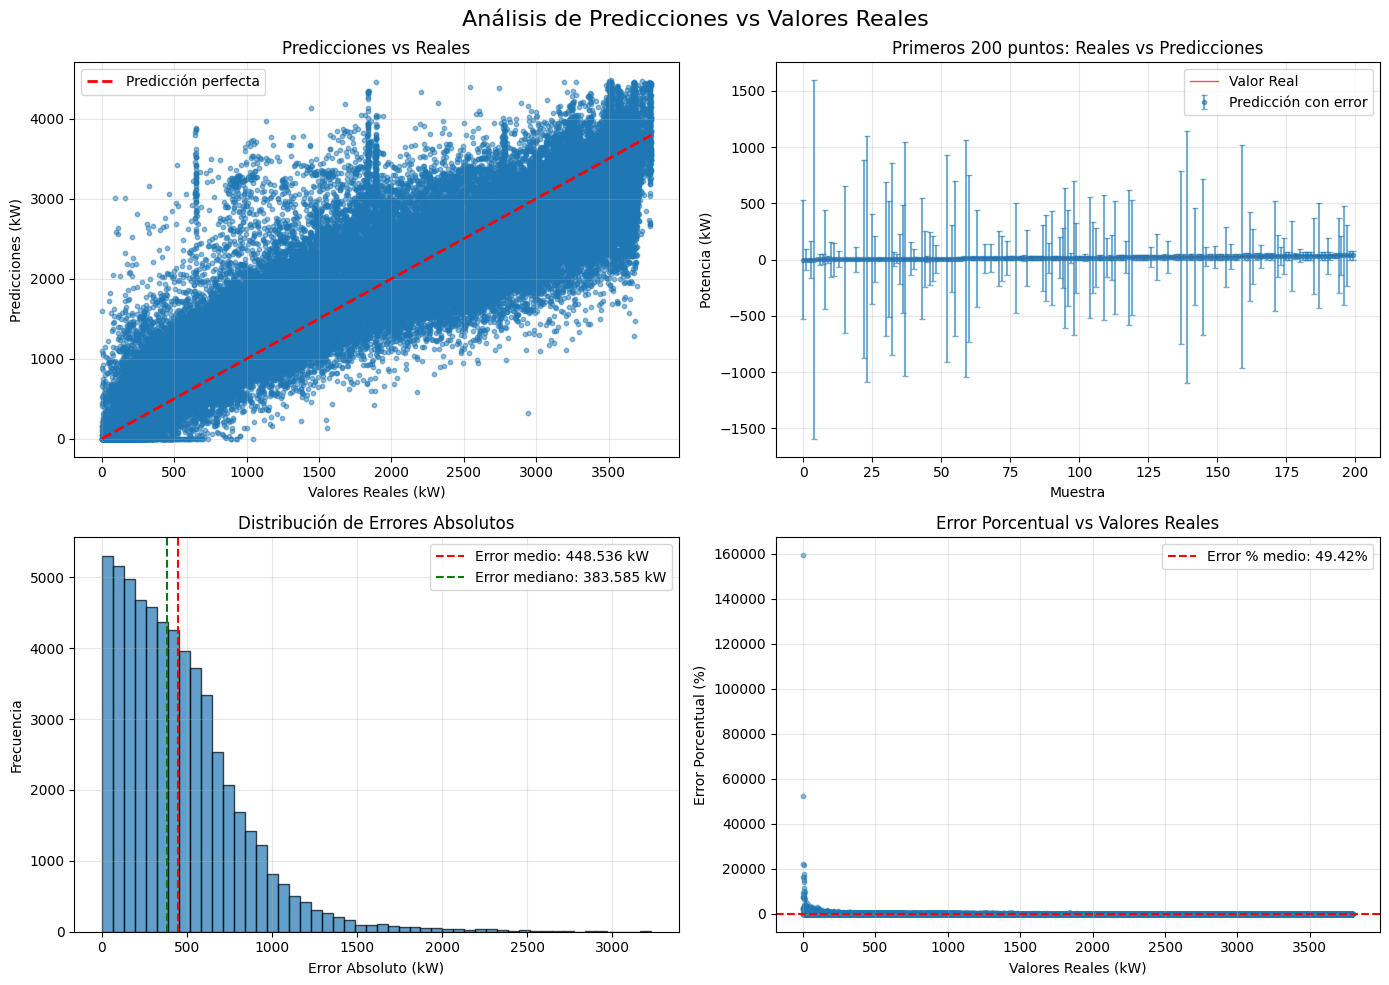


=== MÉTRICAS DE ERROR ===
MAE (Error Absoluto Medio): 448.5362 kW
RMSE: 573.4664 kW
MAPE (Error Porcentual Absoluto Medio): 49.42%
R²: 0.7692


In [21]:
plot_compare_test_pred(y_test_clean, y_pred_clean)

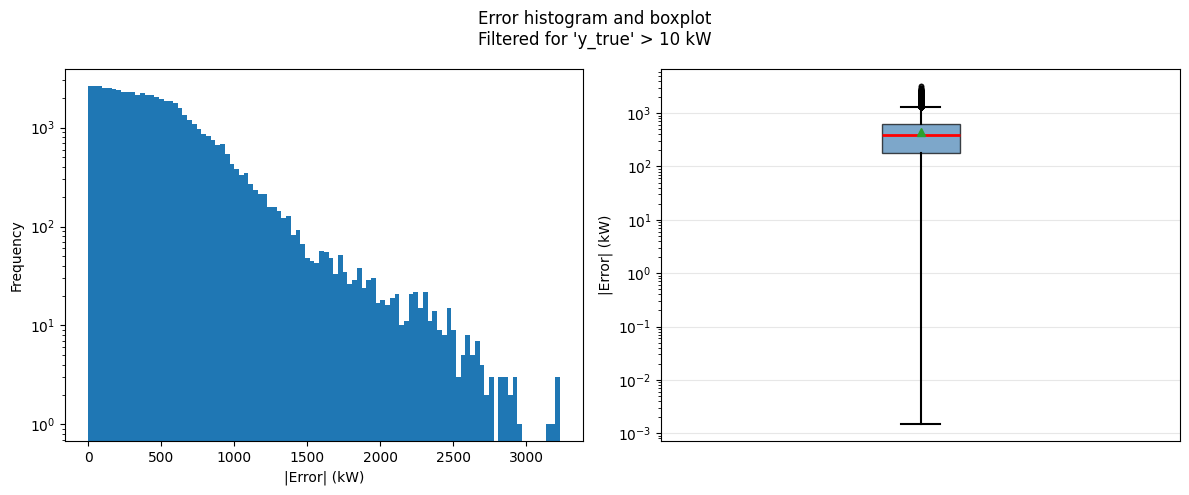

In [22]:
plot_hist_and_boxplot_error(y_test_clean, y_pred_clean)

## Check some conitnuous dates (e.g. whole April)

In [23]:
df_april_2024_curated_full = pd.read_csv("dataset/pvdt_9068_2024_04_curated_full.csv")

from scripts.proccess_previous_to_model import *
df_april_2024_to_fit_all_fields = proccess_previous_to_model_fit(df_april_2024_curated_full)

y_true = df_april_2024_to_fit_all_fields[TARGET]
df_april_2024_to_fit = get_df_for_model(df_april_2024_to_fit_all_fields)

In [24]:
# Z-scaler with previous scaler
# ToDo pickle save it
df_april_2024_to_fit_norm, _ = apply_scaler(df_april_2024_to_fit, scaler=scaler, columns_to_scale=features)

In [25]:
# Filter cols
df_april_2024_to_fit_norm = get_df_for_model(df_april_2024_to_fit_norm)

# Reorder columns to match PCA model's expected order
df_april_2024_to_fit_norm = df_april_2024_to_fit_norm[model_pca.feature_names_in_]

# PCA
df_april_2024_to_fit_norm_pca = model_pca.transform(df_april_2024_to_fit_norm)

# ❗ Apply Gaussian-model
y_pred = model_gaussian.predict(df_april_2024_to_fit_norm_pca)

# Gaussian-Fit did not learn about POA = 0
if True:
    # Set 0.0 if low irradiance (model trained with no night data: training CSVs)
    # Here not needed cause X_test came from those training CSVs
    MIN_POA_WM2 = 50
    mask_low_POA = df_april_2024_to_fit_all_fields["poa_irradiance_wm2"] < MIN_POA_WM2
    y_pred[mask_low_POA] = 0.0

# Evitamos predicciones negativas por seguridad física.
y_pred = np.clip(y_pred, 0, None)

Estadísticas para predicciones con irradiance mayor a 50 W/m2
desde 2024-04-08 09:35:00
hasta 2024-04-30 23:55:00
	Error absoluto medio:   423.913 kW
	Error porcentual medio: 114807255.23%
	Desv. estándar error:   324.773 kW
	Percentil 95 error:     1033.968 kW


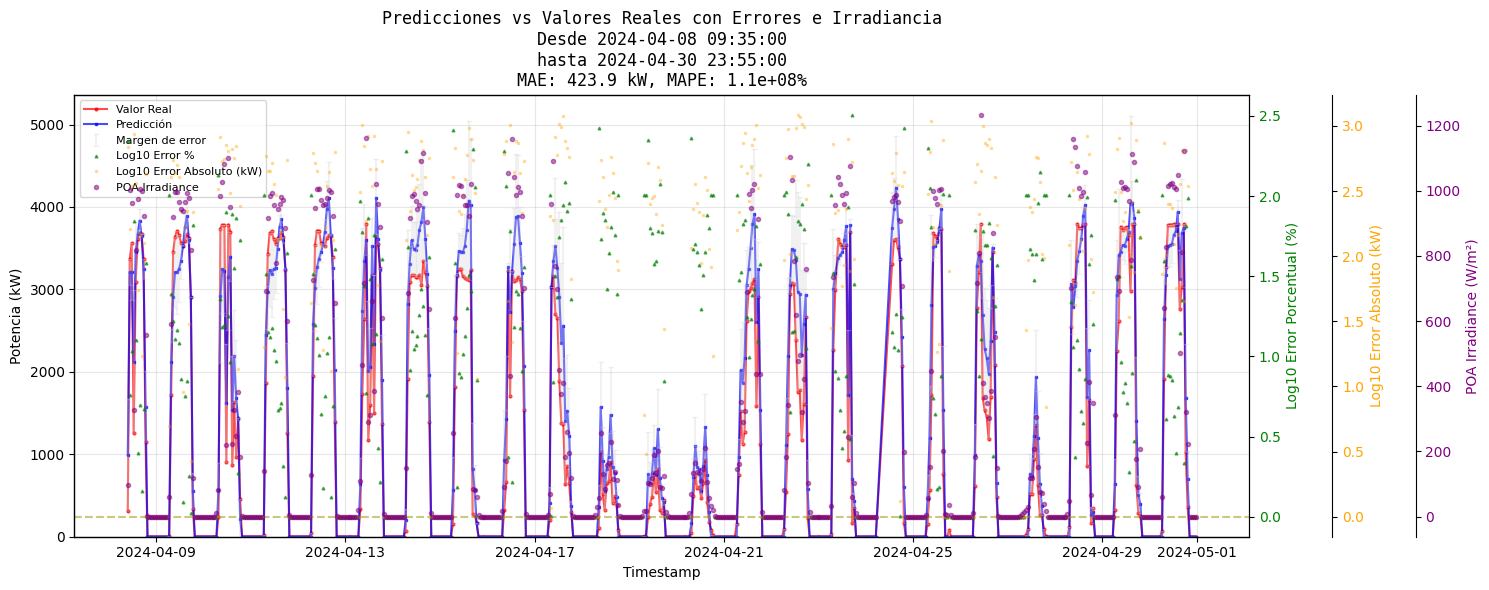

In [26]:
plot_df_pred_true(df_april_2024_to_fit_all_fields, y_true, y_pred);

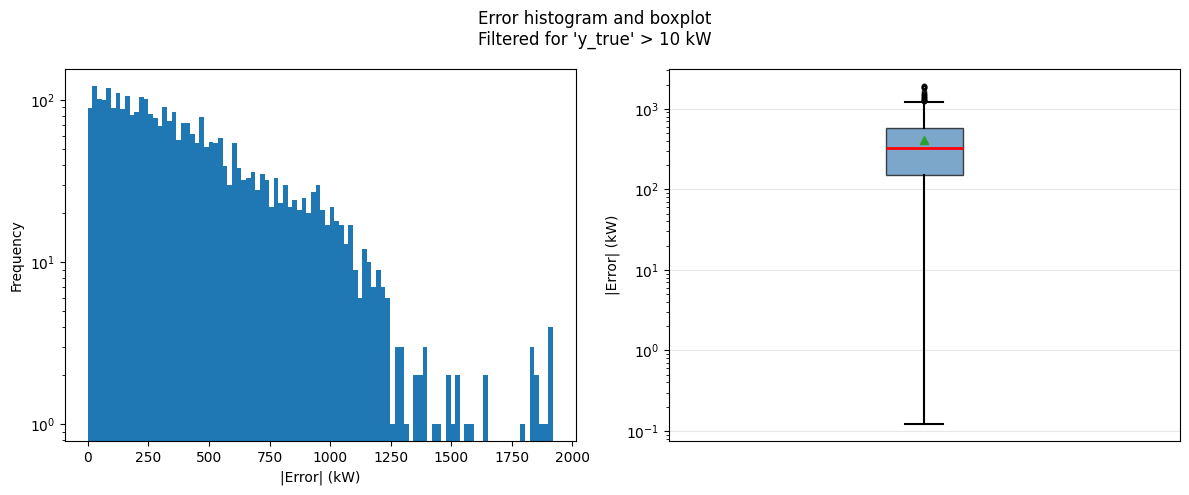

In [27]:
plot_hist_and_boxplot_error(y_true, y_pred)

- The PCA features + Gaussian basis cannot capture the necessary non-linearity beyond what a simple polynomial of degree 2 could.
- The target variable has an inherent limit in how much variance can be explained by these transformed linear models (maybe the noise floor is ~37.4% unexplained variance).

## Store Model

In [28]:
import pickle

# Guardar el modelo
with open('models/gaussianfit_model.pkl', 'wb') as file:
    pickle.dump(model_gaussian, file)

# KernelRidge with RBF hyperparameter search

Needs a lot of memory! --> ERROR

In [29]:
# Hyperparameter grid
# gamma = 1 / (2 * sigma^2) → larger gamma = narrower RBF
# alpha = regularization strength (similar to Ridge)

if False:
    # Best R² = 0.8629 with {'gamma': 1.0, 'alpha': 0.1}
    gamma_arr = [0.01, 0.1, 1.0, 10.0]
    alpha_arr = [0.01, 0.1, 1.0, 10.0]
else:
    gamma_arr = [1.]
    alpha_arr = [1.]


# Data
X, y = model_pca.transform(X_train_clean_norm), y_train_clean

# IMPORTANT: For KernelRidge, training on 287k rows is too large (O(n^2) memory/time)
# Use a random subset for hyperparameter search
train_size=0.1
from sklearn.model_selection import train_test_split
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=train_size, random_state=42)
# Reduce cv
cv = 2

In [30]:
%%time

from sklearn.model_selection import cross_val_score
from sklearn.kernel_ridge import KernelRidge

if False:
    # GridSearchCV stores all models, my df has 290k rows --> huge memory needed
    
    # Pipeline    
    # pipeline = Pipeline([...
    pass

else:
    # Manual grid search – only one model at a time

    best_score = -np.inf
    best_params = None
    
    print("Searching over KernelRidge parameters...")
    for gamma in gamma_arr:
        for alpha in alpha_arr:
            kr = KernelRidge(alpha=alpha, kernel='rbf', gamma=gamma)
            # Use 3-fold CV, sequential computation to avoid memory spikes
            scores = cross_val_score(kr, X_sample, y_sample, cv=cv, 
                                     scoring='r2', n_jobs=-1 if gamma>1.0 else +1, # Avoid n_jobs=-1 to prevent multiple large matrices simultaneously
                                     verbose=0)
            mean_score = scores.mean()
            
            if mean_score > best_score:
                best_score = mean_score
                best_params = {'gamma': gamma, 'alpha': alpha}
            
            print(f"gamma={gamma:5.2f}, alpha={alpha:5.3f}: R² = {mean_score:.4f}")
    
    print(f"\nBest R² = {best_score:.4f} with {best_params}")
    
    # Refit on the FULL data? 
    # Warning: KernelRidge on 287k rows will be extremely slow and memory-heavy.
    # Option: refit on the same sample (used as final model) or subsample further.
    print("\nRefitting best model on full data (this may take a very long time)...")
    model_kr = KernelRidge(**best_params, kernel='rbf')
    try:
        model_kr.fit(X, y)
        # model_kr.fit(X_sample, y_sample) # The kernel dies
    except Exception as e:
        print("Error", e)

Searching over KernelRidge parameters...
gamma= 1.00, alpha=1.000: R² = 0.8566

Best R² = 0.8566 with {'gamma': 1.0, 'alpha': 1.0}

Refitting best model on full data (this may take a very long time)...
Error Unable to allocate 395. GiB for an array with shape (230207, 230207) and data type float64
CPU times: user 1min 38s, sys: 33.3 s, total: 2min 12s
Wall time: 15.6 s


## Check some conitnuous dates (e.g. whole April)

In [31]:
df_april_2024_curated_full = pd.read_csv("dataset/pvdt_9068_2024_04_curated_full.csv")

from scripts.proccess_previous_to_model import *
df_april_2024_to_fit_all_fields = proccess_previous_to_model_fit(df_april_2024_curated_full)

y_true = df_april_2024_to_fit_all_fields[TARGET]
df_april_2024_to_fit = get_df_for_model(df_april_2024_to_fit_all_fields)

In [32]:
# Z-scaler with previous scaler
df_april_2024_to_fit_norm, _ = apply_scaler(df_april_2024_to_fit, scaler=scaler, columns_to_scale=features)

In [33]:
# Filter cols
df_april_2024_to_fit_norm = get_df_for_model(df_april_2024_to_fit_norm)

# Reorder columns to match PCA model's expected order
df_april_2024_to_fit_norm = df_april_2024_to_fit_norm[model_pca.feature_names_in_]

# PCA
df_april_2024_to_fit_norm_pca = model_pca.transform(df_april_2024_to_fit_norm)

# ❗ Apply KR-model --> Fails cause `model_kr.fit()` fails --> Error Unable to allocate 395. GiB for an array with shape (230207, 230207) and data type float64
y_pred = model_kr.predict(df_april_2024_to_fit_norm_pca)


# PolyFit did not learn about POA = 0
if True:
    # Set 0.0 if low irradiance (model trained with no night data: training CSVs)
    # Here not needed cause X_test came from those training CSVs
    MIN_POA_WM2 = 50
    mask_low_POA = df_april_2024_to_fit_all_fields["poa_irradiance_wm2"] < MIN_POA_WM2
    y_pred[mask_low_POA] = 0.0

# Evitamos predicciones negativas por seguridad física.
y_pred = np.clip(y_pred, 0, None)

AttributeError: 'KernelRidge' object has no attribute 'X_fit_'

In [ ]:
plot_df_pred_true(df_april_2024_to_fit_all_fields, y_true, y_pred);

In [ ]:
plot_hist_and_boxplot_error(y_true, y_pred)